In [1]:
%load_ext watermark
%watermark -a "Manuel Elias Orellana Lavayen" -d -v -iv

Author: Manuel Elias Orellana Lavayen

Date: 2026-10-06

Python implementation: CPython
Python version       : 3.12.10
IPython version      : 9.17.1

debugpy: 1.8.22



## Importando Librerias

In [2]:
import polars as pl
from FuncionesModelos import modelos_regresion,modelos_experimentales_clasificacion, modelos_hiperparametros_regresion, modelos_experimentales_clasificacion_2

from polars.lazyframe.engine_config import GPUEngine
config_gpu = GPUEngine(raise_on_fail=True)

from pathlib import Path
ruta_base = Path.cwd()
ruta_base

PosixPath('/espacio_trabajo/Analisis y entrenamiento de modelos')

## Cargando Dataset

In [2]:
variables_categoricas = ["numero_tienda", "cluster", "clase_producto", "familia_producto", "ciudad", "provincia_estado", "tipo_tienda", "numero_articulo"]

otras_variables = ["mes_seno", "mes_coseno", "dia_semana_seno", "dia_semana_coseno", "semana_seno", "semana_coseno", "en_promocion", "perecedero", "es_feriado_nacional", "es_feriado_local", "es_feriado_regional", "es_evento", "unidades_vendidas_ayer", "unidades_vendidas_promedio_semanal", "es_quincena", "petroleo_promedio_3meses"]

variable_predictora = ["unidades_vendidas"]
variable_predictora_2 = ["venta_grande"]
variable_predictora_3 = ["Se vende"]

variables_df = variables_categoricas + otras_variables + variable_predictora
variables_df2 = variables_categoricas + otras_variables + variable_predictora_2
variables_df3 = variables_categoricas + otras_variables + variable_predictora_3

df = (pl.scan_parquet(ruta_base / "Datasets/Concatenados/Limpios/train3.parquet")
      .select(variables_df + ["año"]))

df_2 = (pl.scan_parquet(ruta_base / "Datasets/Concatenados/Limpios/train3.parquet")
      .select(variables_df2 + ["año"]))

df_3 = (pl.scan_parquet(ruta_base / "Datasets/Concatenados/Limpios/train3.parquet")
      .select(variables_df3 + ["año"]))

## Probando diferentes Hiperparametros para los modelos

#### Prueba - 1

In [3]:
param_grid = {
    "max_delta_step" : [5, 10],
    "learning_rate" : [0.1, 0.2, 0.3],
    "gamma" : [0, 3],
    "max_depth" : [6, 8, 10],
    "min_child_weight" : [6000, 7000],
    "lambda_param" : [40, 70],
    "tweedie_variance_power" : [1.1, 1.5]
}

In [5]:
modelos_hiperparametros_regresion(lista_clusters= [1], df= df,periodos_entrenamiento = [2013, 2014], periodo_testeto = [2015], param_grid= param_grid)

------------------------cluster 1------------------------


statistic,value
str,f64
"""count""",4.469e6
"""null_count""",0.0
"""mean""",2.804873
"""std""",10.731963
"""min""",0.0
"""25%""",0.0
"""50%""",0.0
"""75%""",2.0
"""max""",4746.626953



Mejor Combinación --- Mean Absolute Error

max_delta_step            5.0000
learning_rate             0.1000
gamma                     0.0000
max_depth                 8.0000
min_child_weight           6,000
reg_lambda               70.0000
tweedie_variance_power    1.1000
Mean Absolute Error       1.4437
RMSE                      7.1570
R2                        0.5553
NWRMSLE                   0.4904
Name: 10, dtype: float64

Mejor Combinación --- RMSE

max_delta_step           10.0000
learning_rate             0.1000
gamma                     3.0000
max_depth                10.0000
min_child_weight           6,000
reg_lambda               70.0000
tweedie_variance_power    1.1000
Mean Absolute Error       1.4488
RMSE                      7.1403
R2                        0.5573
NWRMSLE                   0.4925
Name: 186, dtype: float64

Mejor Combinación --- R2

max_delta_step           10.0000
learning_rate             0.1000
gamma                     3.0000
max_depth               

In [4]:
modelos_hiperparametros_regresion(lista_clusters= [7], df= df,periodos_entrenamiento = [2013, 2014], periodo_testeto = [2015], param_grid= param_grid)

------------------------cluster 7------------------------


statistic,value
str,f64
"""count""",1.8286e6
"""null_count""",0.0
"""mean""",1.661469
"""std""",7.320323
"""min""",0.0
"""25%""",0.0
"""50%""",0.0
"""75%""",1.0
"""max""",4738.0



Mejor Combinación --- Mean Absolute Error

max_delta_step           10.0000
learning_rate             0.2000
gamma                     0.0000
max_depth                10.0000
min_child_weight           6,000
reg_lambda               70.0000
tweedie_variance_power    1.5000
Mean Absolute Error       1.0261
RMSE                      5.8054
R2                        0.3711
NWRMSLE                   0.4398
Name: 211, dtype: float64

Mejor Combinación --- RMSE

max_delta_step           10.0000
learning_rate             0.1000
gamma                     3.0000
max_depth                 8.0000
min_child_weight           6,000
reg_lambda               70.0000
tweedie_variance_power    1.1000
Mean Absolute Error       1.0350
RMSE                      5.7337
R2                        0.3865
NWRMSLE                   0.4468
Name: 178, dtype: float64

Mejor Combinación --- R2

max_delta_step           10.0000
learning_rate             0.1000
gamma                     3.0000
max_depth              

In [4]:
modelos_hiperparametros_regresion(lista_clusters= [13], df= df,periodos_entrenamiento = [2013, 2014], periodo_testeto = [2015], param_grid= param_grid)

------------------------cluster 13------------------------


statistic,value
str,f64
"""count""",5.9491e6
"""null_count""",0.0
"""mean""",2.696643
"""std""",9.403148
"""min""",0.0
"""25%""",0.0
"""50%""",0.0
"""75%""",3.0
"""max""",4800.0



Mejor Combinación --- Mean Absolute Error

max_delta_step            5.0000
learning_rate             0.1000
gamma                     3.0000
max_depth                10.0000
min_child_weight           7,000
reg_lambda               40.0000
tweedie_variance_power    1.1000
Mean Absolute Error       1.4106
RMSE                      6.8903
R2                        0.4631
NWRMSLE                   0.4842
Name: 44, dtype: float64

Mejor Combinación --- RMSE

max_delta_step            5.0000
learning_rate             0.1000
gamma                     0.0000
max_depth                10.0000
min_child_weight           7,000
reg_lambda               70.0000
tweedie_variance_power    1.5000
Mean Absolute Error       1.4150
RMSE                      6.8543
R2                        0.4687
NWRMSLE                   0.4850
Name: 23, dtype: float64

Mejor Combinación --- R2

max_delta_step            5.0000
learning_rate             0.1000
gamma                     0.0000
max_depth                

#### Prueba - 2

In [3]:
param_grid = {
    "max_delta_step" : [5, 7, 10],
    "learning_rate" : [0.1],
    "gamma" : [3, 4],
    "max_depth" : [8, 10],
    "min_child_weight" : [6000, 7000],
    "lambda_param" : [70],
    "tweedie_variance_power" : [1.1, 1.5]
}

In [4]:
modelos_hiperparametros_regresion(lista_clusters= [1, 2], df= df,periodos_entrenamiento = [2013, 2014], periodo_testeto = [2015], param_grid= param_grid)

------------------------cluster 1------------------------


statistic,value
str,f64
"""count""",4.469e6
"""null_count""",0.0
"""mean""",2.804873
"""std""",10.731963
"""min""",0.0
"""25%""",0.0
"""50%""",0.0
"""75%""",2.0
"""max""",4746.626953



Mejor Combinación --- Mean Absolute Error

max_delta_step            7.0000
learning_rate             0.1000
gamma                     3.0000
max_depth                10.0000
min_child_weight           7,000
reg_lambda               70.0000
tweedie_variance_power    1.1000
Mean Absolute Error       1.4413
RMSE                      7.1480
R2                        0.5564
NWRMSLE                   0.4888
Name: 22, dtype: float64

Mejor Combinación --- RMSE

max_delta_step           10.0000
learning_rate             0.1000
gamma                     4.0000
max_depth                10.0000
min_child_weight           6,000
reg_lambda               70.0000
tweedie_variance_power    1.1000
Mean Absolute Error       1.4483
RMSE                      7.1205
R2                        0.5598
NWRMSLE                   0.4913
Name: 44, dtype: float64

Mejor Combinación --- R2

max_delta_step           10.0000
learning_rate             0.1000
gamma                     4.0000
max_depth                

statistic,value
str,f64
"""count""",2.0295e6
"""null_count""",0.0
"""mean""",2.991009
"""std""",9.445025
"""min""",0.0
"""25%""",0.0
"""50%""",0.0
"""75%""",3.0
"""max""",2411.0



Mejor Combinación --- Mean Absolute Error

max_delta_step            5.0000
learning_rate             0.1000
gamma                     3.0000
max_depth                10.0000
min_child_weight           6,000
reg_lambda               70.0000
tweedie_variance_power    1.5000
Mean Absolute Error       1.5668
RMSE                      6.0144
R2                        0.5945
NWRMSLE                   0.5134
Name: 5, dtype: float64

Mejor Combinación --- RMSE

max_delta_step            5.0000
learning_rate             0.1000
gamma                     3.0000
max_depth                10.0000
min_child_weight           6,000
reg_lambda               70.0000
tweedie_variance_power    1.1000
Mean Absolute Error       1.6025
RMSE                      5.9695
R2                        0.6005
NWRMSLE                   0.5259
Name: 4, dtype: float64

Mejor Combinación --- R2

max_delta_step            5.0000
learning_rate             0.1000
gamma                     3.0000
max_depth                10

In [5]:
modelos_hiperparametros_regresion(lista_clusters= [7, 8], df= df,periodos_entrenamiento = [2013, 2014], periodo_testeto = [2015], param_grid= param_grid)

------------------------cluster 7------------------------


statistic,value
str,f64
"""count""",1.8286e6
"""null_count""",0.0
"""mean""",1.661469
"""std""",7.320323
"""min""",0.0
"""25%""",0.0
"""50%""",0.0
"""75%""",1.0
"""max""",4738.0



Mejor Combinación --- Mean Absolute Error

max_delta_step            5.0000
learning_rate             0.1000
gamma                     3.0000
max_depth                10.0000
min_child_weight           6,000
reg_lambda               70.0000
tweedie_variance_power    1.5000
Mean Absolute Error       1.0285
RMSE                      5.8346
R2                        0.3647
NWRMSLE                   0.4415
Name: 5, dtype: float64

Mejor Combinación --- RMSE

max_delta_step           10.0000
learning_rate             0.1000
gamma                     3.0000
max_depth                 8.0000
min_child_weight           6,000
reg_lambda               70.0000
tweedie_variance_power    1.1000
Mean Absolute Error       1.0350
RMSE                      5.7337
R2                        0.3865
NWRMSLE                   0.4468
Name: 32, dtype: float64

Mejor Combinación --- R2

max_delta_step           10.0000
learning_rate             0.1000
gamma                     3.0000
max_depth                 

statistic,value
str,f64
"""count""",4.4649e6
"""null_count""",0.0
"""mean""",5.371205
"""std""",16.965481
"""min""",0.0
"""25%""",0.0
"""50%""",0.0
"""75%""",5.0
"""max""",1680.984009



Mejor Combinación --- Mean Absolute Error

max_delta_step            5.0000
learning_rate             0.1000
gamma                     4.0000
max_depth                10.0000
min_child_weight           7,000
reg_lambda               70.0000
tweedie_variance_power    1.5000
Mean Absolute Error       2.1876
RMSE                      7.6446
R2                        0.7970
NWRMSLE                   0.4949
Name: 15, dtype: float64

Mejor Combinación --- RMSE

max_delta_step            5.0000
learning_rate             0.1000
gamma                     4.0000
max_depth                10.0000
min_child_weight           7,000
reg_lambda               70.0000
tweedie_variance_power    1.5000
Mean Absolute Error       2.1876
RMSE                      7.6446
R2                        0.7970
NWRMSLE                   0.4949
Name: 15, dtype: float64

Mejor Combinación --- R2

max_delta_step            5.0000
learning_rate             0.1000
gamma                     4.0000
max_depth                

In [4]:
modelos_hiperparametros_regresion(lista_clusters= [10, 12], df= df,periodos_entrenamiento = [2013, 2014], periodo_testeto = [2015], param_grid= param_grid)

------------------------cluster 10------------------------


statistic,value
str,f64
"""count""",8.6141e6
"""null_count""",0.0
"""mean""",2.363808
"""std""",10.924268
"""min""",0.0
"""25%""",0.0
"""50%""",0.0
"""75%""",1.826
"""max""",12016.0



Mejor Combinación --- Mean Absolute Error

max_delta_step            5.0000
learning_rate             0.1000
gamma                     3.0000
max_depth                 8.0000
min_child_weight           6,000
reg_lambda               70.0000
tweedie_variance_power    1.5000
Mean Absolute Error       1.3271
RMSE                      8.2994
R2                        0.4228
NWRMSLE                   0.4625
Name: 1, dtype: float64

Mejor Combinación --- RMSE

max_delta_step            5.0000
learning_rate             0.1000
gamma                     3.0000
max_depth                10.0000
min_child_weight           6,000
reg_lambda               70.0000
tweedie_variance_power    1.5000
Mean Absolute Error       1.3286
RMSE                      8.2795
R2                        0.4256
NWRMSLE                   0.4627
Name: 5, dtype: float64

Mejor Combinación --- R2

max_delta_step            5.0000
learning_rate             0.1000
gamma                     3.0000
max_depth                10

statistic,value
str,f64
"""count""",1.4883e6
"""null_count""",0.0
"""mean""",2.628723
"""std""",10.944713
"""min""",0.0
"""25%""",0.0
"""50%""",0.0
"""75%""",2.0
"""max""",3607.0



Mejor Combinación --- Mean Absolute Error

max_delta_step           10.0000
learning_rate             0.1000
gamma                     3.0000
max_depth                10.0000
min_child_weight           6,000
reg_lambda               70.0000
tweedie_variance_power    1.1000
Mean Absolute Error       1.3247
RMSE                      7.7469
R2                        0.4990
NWRMSLE                   0.4270
Name: 36, dtype: float64

Mejor Combinación --- RMSE

max_delta_step           10.0000
learning_rate             0.1000
gamma                     3.0000
max_depth                 8.0000
min_child_weight           6,000
reg_lambda               70.0000
tweedie_variance_power    1.1000
Mean Absolute Error       1.3317
RMSE                      7.7423
R2                        0.4996
NWRMSLE                   0.4286
Name: 32, dtype: float64

Mejor Combinación --- R2

max_delta_step           10.0000
learning_rate             0.1000
gamma                     3.0000
max_depth                

## Entrenando modelos experimentales con mejores hiperparametros encontrados

#### Peso Artículos Perecederos -> False

In [3]:
diccionario_modelos_experimentales_regresion = modelos_regresion(lista_clusters=[1, 4, 5, 8, 9, 10, 13, 16], df= df, periodos_entrenamiento = [2013, 2014, 2015, 2016], periodo_testeto= [2017], pesos_perecedero = False)

------------------------cluster 1------------------------
Descripción de datos


statistic,value
str,f64
"""count""",2.7839e6
"""null_count""",0.0
"""mean""",3.48556
"""std""",10.768795
"""min""",0.0
"""25%""",0.0
"""50%""",0.0
"""75%""",3.0
"""max""",2987.0


Métricas


,Resultados
Predicción Maxima,506
Predicción Minima,0.0007
Ventas Reales,"9,703,454"
Ventas Predichas,"9,641,959"
Mean Absolute Error,1.8808
Median Absolute Error,0.6892
RMSE,6.1961
Max Error,"2,921"
R2,0.6689
NWRMSLE,0.5796


Rendimiento por bloques de unidades vendidas


...

statistic,value
str,f64
"""count""",926600.0
"""null_count""",0.0
"""mean""",2.778246
"""std""",8.742009
"""min""",0.0
"""25%""",0.0
"""50%""",0.0
"""75%""",3.0
"""max""",2886.0


Métricas


,Resultados
Predicción Maxima,187
Predicción Minima,0.0008
Ventas Reales,"2,574,322"
Ventas Predichas,"2,632,842"
Mean Absolute Error,1.6587
Median Absolute Error,0.6150
RMSE,6.1613
Max Error,"2,883"
R2,0.5033
NWRMSLE,0.5617


Rendimiento por bloques de unidades vendidas


bloque,0,1-5,6-20,21-50,51-100,101-500,>500
cantidad,"482,996","316,730","102,879","16,289","2,860",766,8.0000
porcentaje,52.1256,34.1820,11.1028,1.7579,0.3087,0.0827,0.0009
MAE,0.6118,1.4961,4.2579,11.0054,25.1560,75.9999,"1,170"
RMSE,1.4952,2.4423,5.6897,13.8298,30.8683,101,"1,374"
Ventas Reales,0.0000,"740,629","1,012,716","483,777","194,203","114,253","9,521"
Ventas Predichas,"295,474","917,003","839,502","367,322","133,981","56,664",165
NWRMSLE,0.5795,0.5029,0.6009,0.6770,0.8150,1.2733,4.4862


#### Peso Artículos Perecederos -> True

In [4]:
diccionario_modelos_experimentales_regresion = modelos_regresion(lista_clusters=[1, 4, 5, 8, 9, 10, 13, 16], df= df, periodos_entrenamiento = [2013, 2014, 2015, 2016], periodo_testeto= [2017], pesos_perecedero = True)

------------------------cluster 1------------------------
Descripción de datos


statistic,value
str,f64
"""count""",2.7839e6
"""null_count""",0.0
"""mean""",3.48556
"""std""",10.768795
"""min""",0.0
"""25%""",0.0
"""50%""",0.0
"""75%""",3.0
"""max""",2987.0


Métricas


,Resultados
Predicción Maxima,404
Predicción Minima,0.0004
Ventas Reales,"9,703,454"
Ventas Predichas,"9,655,618"
Mean Absolute Error,1.8856
Median Absolute Error,0.6891
RMSE,6.2752
Max Error,"2,913"
R2,0.6604
NWRMSLE,0.5799


Rendimiento por bloques de unidades vendidas


...

statistic,value
str,f64
"""count""",926600.0
"""null_count""",0.0
"""mean""",2.778246
"""std""",8.742009
"""min""",0.0
"""25%""",0.0
"""50%""",0.0
"""75%""",3.0
"""max""",2886.0


Métricas


,Resultados
Predicción Maxima,178
Predicción Minima,0.0006
Ventas Reales,"2,574,322"
Ventas Predichas,"2,634,375"
Mean Absolute Error,1.6538
Median Absolute Error,0.6184
RMSE,6.1466
Max Error,"2,882"
R2,0.5056
NWRMSLE,0.5615


Rendimiento por bloques de unidades vendidas


bloque,0,1-5,6-20,21-50,51-100,101-500,>500
cantidad,"482,996","316,730","102,879","16,289","2,860",766,8.0000
porcentaje,52.1256,34.1820,11.1028,1.7579,0.3087,0.0827,0.0009
MAE,0.6122,1.4917,4.2254,11.0253,25.2650,74.9717,"1,168"
RMSE,1.4907,2.4121,5.6352,13.8702,31.0410,101,"1,373"
Ventas Reales,0.0000,"740,629","1,012,716","483,777","194,203","114,253","9,521"
Ventas Predichas,"295,705","916,079","838,706","368,565","134,297","57,579",175
NWRMSLE,0.5799,0.5021,0.5983,0.6770,0.8173,1.2770,4.4603


###  Conclusión de comparativa de Pesos Perecederos (True - False)

En una comparación directa de métricas, los modelos a los que se agregó pesos en el entrenamiento para los productos perecederos no presentó una mejora significativa en la mayoría de sus clusters, por lo que se considera el modelo sis pesos para productos perecederos es el más apropiado

## Entrenando Modelos de Clasificación de Pico de Ventas Para Posible Modelo de Dos Etapas

------------------------cluster 1------------------------


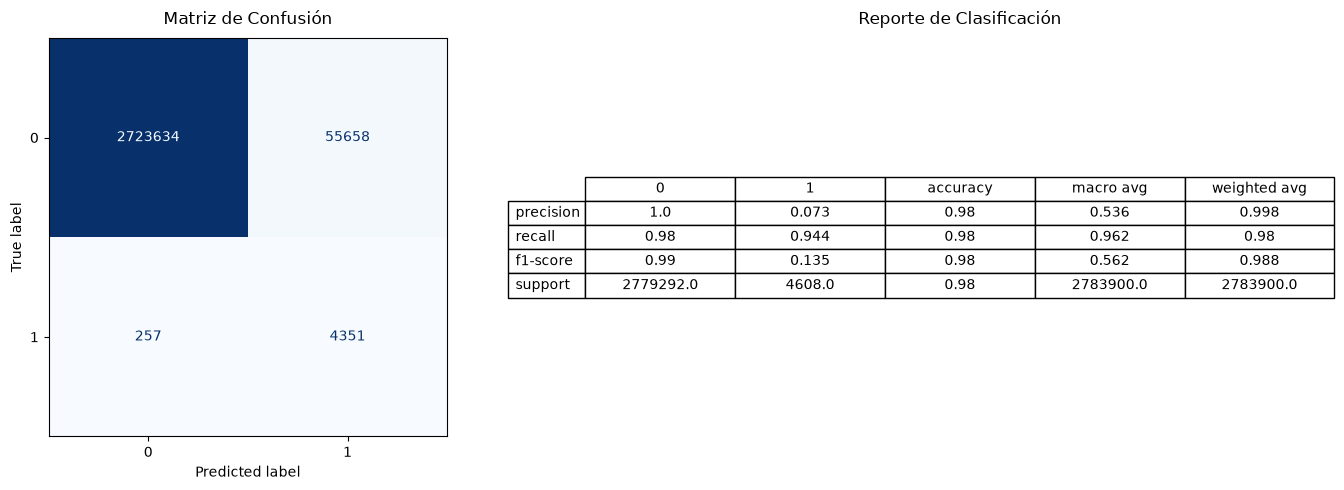

------------------------cluster 2------------------------


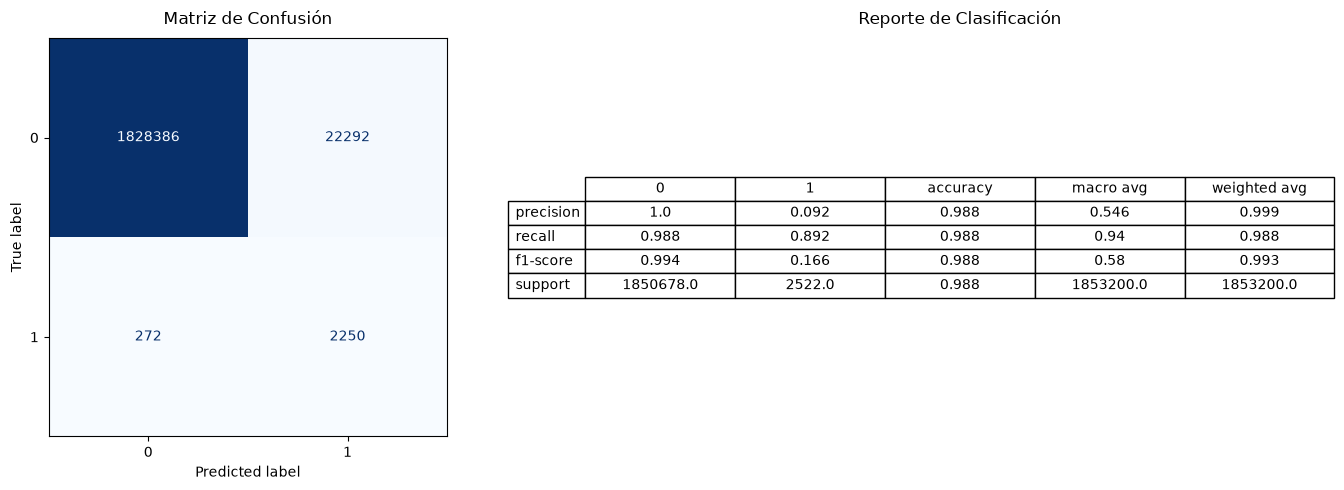

In [5]:
diccionario_modelos_experimentales_clasificacion = modelos_experimentales_clasificacion(lista_clusters=[1, 2], df= df_2, periodos_entrenamiento = [2013, 2014, 2015, 2016], periodo_testeto= [2017])

## Entrenando Modelos de Clasificación de Venta de productos (Si un producto se vende o no)

------------------------cluster 1------------------------


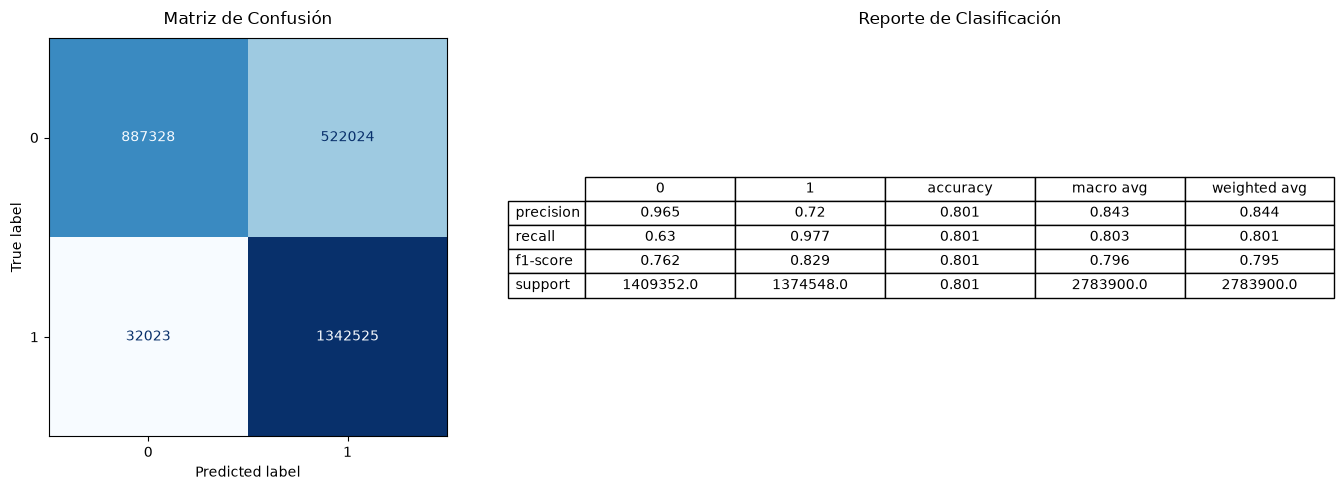

------------------------cluster 2------------------------


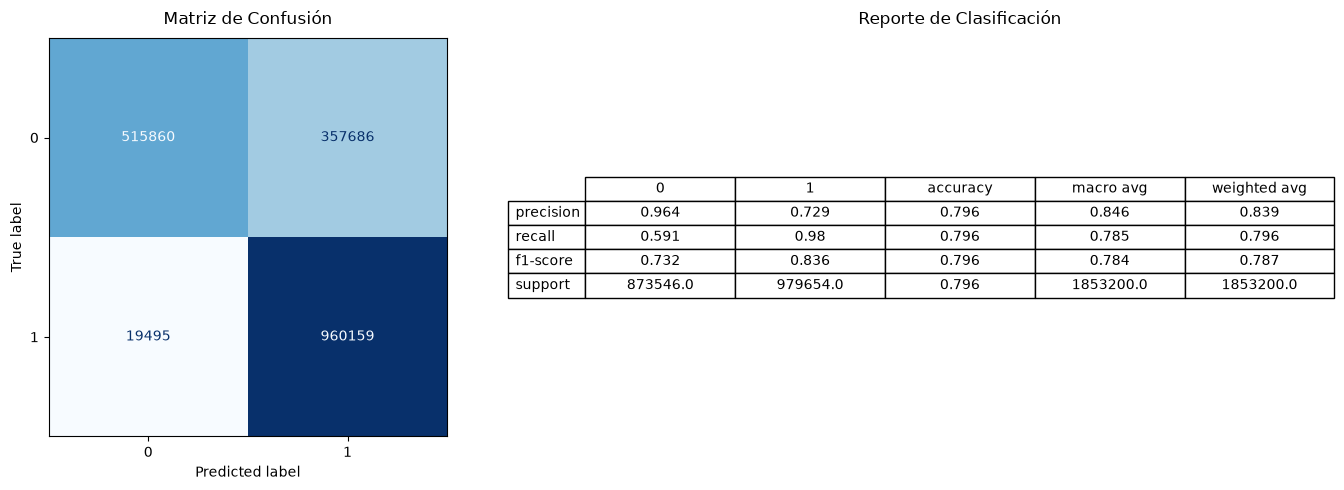

In [6]:
diccionario_modelos_experimentales_clasificacion = modelos_experimentales_clasificacion_2(lista_clusters=[1, 2], df= df_3, periodos_entrenamiento = [2013, 2014, 2015, 2016], periodo_testeto= [2017])

### Conclusión de Modelos de Clasificación para Modelo de dos etapas

Ninguno de los modelos presenta un rendimiento decente como filtro, ya que a pesar de conseguir buenas métricas precision o buen recall, flaquean en su contraparte, lo que hace que muchos valores que no son, sean clasificados, perjudicando el rendimiento final del modelo principal